# Chapter 2, Applied Exercise 8 — The `College` Data Set

This notebook works through ISLP Chapter 2, Exercise 8, using `College.csv`
(777 US colleges and universities, 18 variables: admissions, cost, faculty,
and outcome measures).

**Sections:** (a) load data · (b) fix the index · (c) `describe()` summary ·
(d) scatterplot matrix · (e) `Outstate` vs `Private` boxplots ·
(f) create `Elite` and compare `Outstate` vs `Elite` · (g) histograms ·
(h) further exploration and summary of findings.

### (a) Read the data into Python with `pd.read_csv()`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

college = pd.read_csv('College.csv')
college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


### (b) Fix the index

The first column has no header in the CSV, so `pandas` loads it as a data
column called `Unnamed: 0` rather than using it as the row index. We rename
it to `College` and set it as the index, so each row is properly labeled by
university name and `Private` becomes the first real data column.

In [2]:
college2 = pd.read_csv('College.csv', index_col=0)
college3 = college.rename({'Unnamed: 0': 'College'}, axis=1)
college3 = college3.set_index('College')
college = college3
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
College,,,,,,,,,,,,,,,,,,
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


### (c) Numerical summary with `describe()`

In [3]:
college.describe()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
count,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.000000,777.00000
mean,3001.638353,2018.804376,779.972973,27.558559,55.796654,3699.907336,855.298584,10440.669241,4357.526384,549.380952,1340.642214,72.660232,79.702703,14.089704,22.743887,9660.171171,65.46332
std,3870.201484,2451.113971,929.176190,17.640364,19.804778,4850.420531,1522.431887,4023.016484,1096.696416,165.105360,677.071454,16.328155,14.722359,3.958349,12.391801,5221.768440,17.17771
min,81.000000,72.000000,35.000000,1.000000,9.000000,139.000000,1.000000,2340.000000,1780.000000,96.000000,250.000000,8.000000,24.000000,2.500000,0.000000,3186.000000,10.00000
25%,776.000000,604.000000,242.000000,15.000000,41.000000,992.000000,95.000000,7320.000000,3597.000000,470.000000,850.000000,62.000000,71.000000,11.500000,13.000000,6751.000000,53.00000
50%,1558.000000,1110.000000,434.000000,23.000000,54.000000,1707.000000,353.000000,9990.000000,4200.000000,500.000000,1200.000000,75.000000,82.000000,13.600000,21.000000,8377.000000,65.00000
75%,3624.000000,2424.000000,902.000000,35.000000,69.000000,4005.000000,967.000000,12925.000000,5050.000000,600.000000,1700.000000,85.000000,92.000000,16.500000,31.000000,10830.000000,78.00000
max,48094.000000,26330.000000,6392.000000,96.000000,100.000000,31643.000000,21836.000000,21700.000000,8124.000000,2340.000000,6800.000000,103.000000,100.000000,39.800000,64.000000,56233.000000,118.00000


### (d) Scatterplot matrix of `Top10perc`, `Apps`, `Enroll`

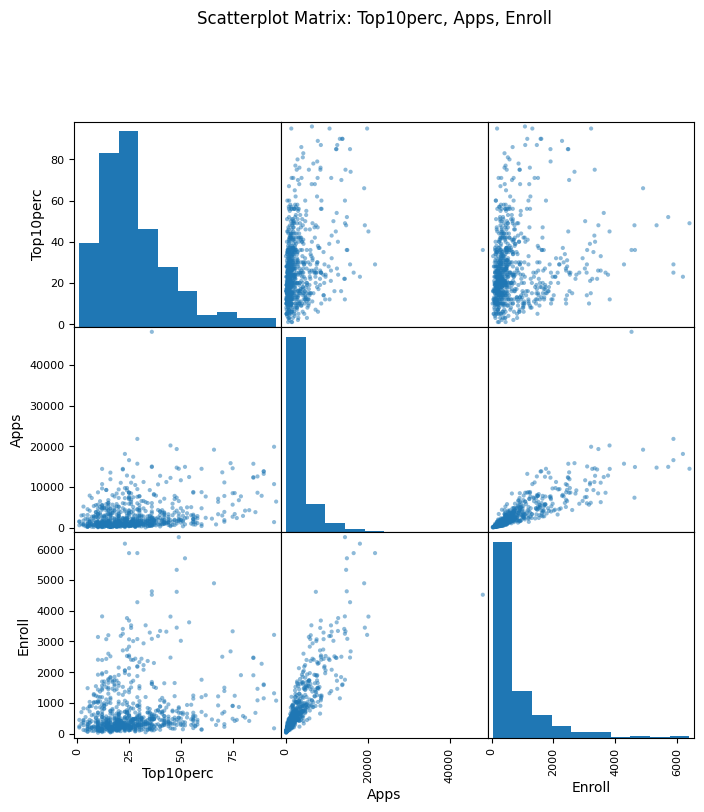

In [4]:
pd.plotting.scatter_matrix(college[['Top10perc', 'Apps', 'Enroll']],
                            figsize=(8, 8));
plt.suptitle('Scatterplot Matrix: Top10perc, Apps, Enroll', y=1.02)
plt.show()

### (e) Side-by-side boxplots of `Outstate` versus `Private`

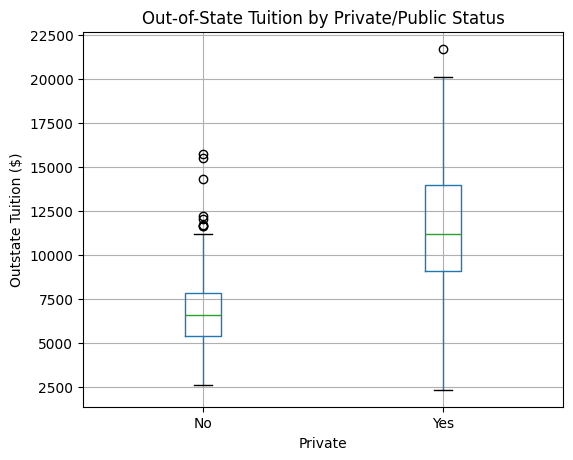

In [5]:
college.boxplot(column='Outstate', by='Private', figsize=(6, 5))
plt.title('Out-of-State Tuition by Private/Public Status')
plt.suptitle('')
plt.ylabel('Outstate Tuition ($)')
plt.show()

### (f) Create the `Elite` variable

Bin `Top10perc` into two groups: `Elite = 'Yes'` if more than 50% of a
college's new students came from the top 10% of their high school class,
otherwise `'No'`.

In [6]:
college['Elite'] = pd.cut(college['Top10perc'],
                          [0, 50, 100],
                          labels=['No', 'Yes'])
college['Elite'].value_counts()

Elite
No     699
Yes     78
Name: count, dtype: int64

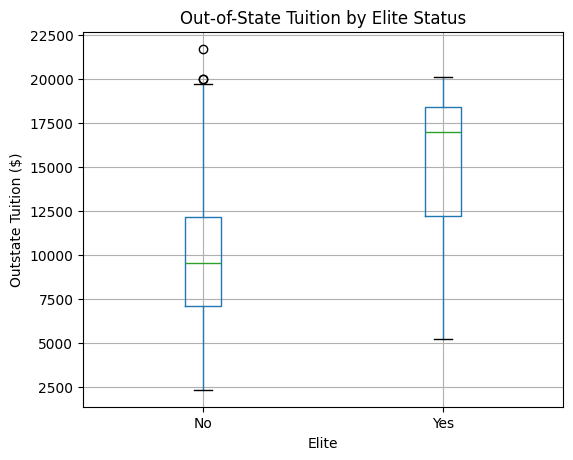

In [7]:
college.boxplot(column='Outstate', by='Elite', figsize=(6, 5))
plt.title('Out-of-State Tuition by Elite Status')
plt.suptitle('')
plt.ylabel('Outstate Tuition ($)')
plt.show()

### (g) Histograms with differing bin counts

`plt.subplots(2, 2)` divides the figure into a 2x2 grid so four histograms
(each with a different number of bins) can be shown at once.

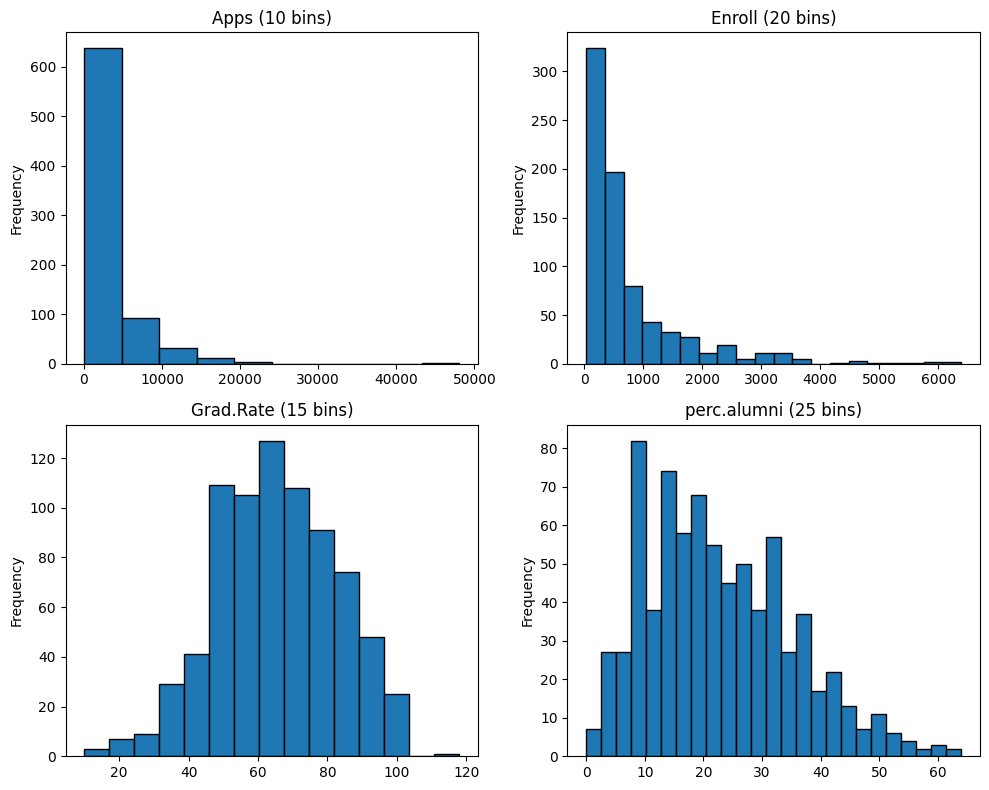

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

college['Apps'].plot.hist(ax=axes[0, 0], bins=10, edgecolor='black')
axes[0, 0].set_title('Apps (10 bins)')

college['Enroll'].plot.hist(ax=axes[0, 1], bins=20, edgecolor='black')
axes[0, 1].set_title('Enroll (20 bins)')

college['Grad.Rate'].plot.hist(ax=axes[1, 0], bins=15, edgecolor='black')
axes[1, 0].set_title('Grad.Rate (15 bins)')

college['perc.alumni'].plot.hist(ax=axes[1, 1], bins=25, edgecolor='black')
axes[1, 1].set_title('perc.alumni (25 bins)')

plt.tight_layout()
plt.show()

### (h) Continue exploring the data

A few more angles: which variables correlate most strongly with graduation
rate, how expenditure per student relates to Outstate tuition, and where the
`Grad.Rate` outlier(s) are.

In [9]:
correlations = college.select_dtypes(include=[np.number]).corr()['Grad.Rate'].sort_values(ascending=False)
correlations

Grad.Rate      1.000000
Outstate       0.571290
Top10perc      0.494989
perc.alumni    0.490898
Top25perc      0.477281
Room.Board     0.424942
Expend         0.390343
PhD            0.305038
Terminal       0.289527
Apps           0.146755
Accept         0.067313
Books          0.001061
Enroll        -0.022341
F.Undergrad   -0.078773
P.Undergrad   -0.257001
Personal      -0.269344
S.F.Ratio     -0.306710
Name: Grad.Rate, dtype: float64

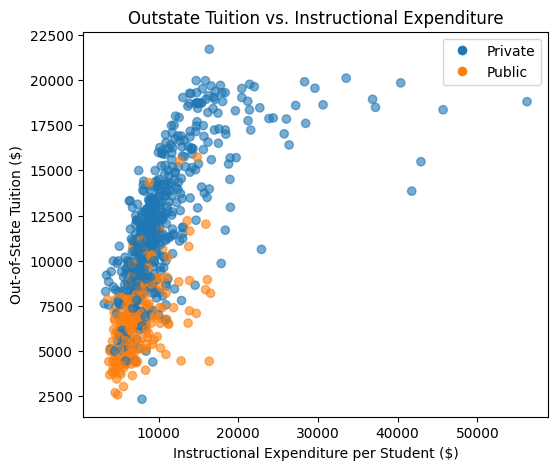

In [10]:
plt.figure(figsize=(6, 5))
colors = college['Private'].map({'Yes': 'tab:blue', 'No': 'tab:orange'})
plt.scatter(college['Expend'], college['Outstate'], c=colors, alpha=0.6)
plt.xlabel('Instructional Expenditure per Student ($)')
plt.ylabel('Out-of-State Tuition ($)')
plt.title('Outstate Tuition vs. Instructional Expenditure')
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', label='Private', markersize=8),
                     plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', label='Public', markersize=8)])
plt.show()

In [11]:
# Colleges with a graduation rate above 100% (a known data-entry artifact in this dataset)
college[college['Grad.Rate'] > 100]

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Elite
College,,,,,,,,,,,,,,,,,,,
Cazenovia College,Yes,3847,3433,527,9,35,1010,12,9384,4840,600,500,22,47,14.3,20,7697,118,No


**Summary of findings:**

- `Grad.Rate` correlates most strongly with `Outstate`, `Top25perc`,
  `Top10perc`, and `perc.alumni` — colleges that are pricier, more
  selective, and have more engaged alumni tend to graduate more students.
- Private colleges charge far higher out-of-state tuition than public ones,
  and elite colleges (by the `Top10perc` cutoff) charge noticeably more
  than non-elite colleges — consistent with elite status being tied to more
  resources per student.
- `Outstate` tuition rises with instructional `Expend`, though the
  relationship is noisy and mostly driven by private schools, which cluster
  at higher spending and higher tuition than public schools.
- One college (Cazenovia College) has a `Grad.Rate` above 100%, which is
  impossible and is a data-entry error worth flagging or capping at 100
  before further analysis.
- `Apps`, `Accept`, and `Enroll` are all strongly right-skewed (most schools
  are small to mid-sized, with a long tail of large universities receiving
  tens of thousands of applications), which the histograms in (g) make clear.